In [1]:
from music21 import stream, note, meter, key, clef, dynamics, expressions, layout, tempo
from collections import defaultdict, Counter
import os
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random


In [2]:
with open('rhythm_dict/rhythm_dict_with_cleanup_20dec25.pkl', 'rb') as f:
    rhythm_dict = pickle.load(f)

with open('markov_dict/pitch_markov_restrictedG3E6.pkl', 'rb') as f:
    pitch_markov_prob = pickle.load(f)

with open('hand_pattern_dict/hand_patterns_grade1.pkl', 'rb') as f:
    transition_patterns = pickle.load(f)

with open('expressive_dict/expressive_marks_grade1.pkl', 'rb') as f:
    expressive_dict = pickle.load(f)

In [3]:
# ===============================
# GRADE SETTINGS
# ===============================

GRADE_SETTINGS = {
        
    "initial": {
        "structures": [
            {"bars": 4, "time_signature": "4/4"},
            {"bars": 6, "time_signature": "2/4"}
        ],
        "keys": ["C_major", "D_minor"],
        "position": "5_finger"
    },

    1: {

        "structures": [
            {"bars": 4, "time_signature": "4/4"},
            {"bars": 4, "time_signature": "3/4"},
            {"bars": 6, "time_signature": "2/4"}
        ],

        "keys": [
            "C_major",
            "D_minor",
            "G_major",
            "F_major",
            "A_minor"
        ],
        "position": "any_5_finger"
    }
}

def sample_grade_parameters(grade):

    settings = GRADE_SETTINGS[grade]

    structure = random.choice(settings["structures"])

    difficulty = DIFFICULTY_PROFILES[grade]

    params = {
        "bars": structure["bars"],
        "time_signature": structure["time_signature"],
        "key": random.choice(settings["keys"]),
        "position": settings["position"],
        "max_interval": difficulty["max_interval"],
        "allowed_durations": difficulty["allowed_durations"]
    }

    # Initial grade uses one hand only
    if grade == "initial":
        params["hand"] = random.choice(["RH", "LH"])

    return params

# ===============================
# DIFFICULTY ENGINE
# ===============================

DIFFICULTY_PROFILES = {

    "initial": {

        "max_interval": 4,
        "preferred_interval": 2,

        "range": (55, 76),

        "use_position_range": True,

        "allowed_durations": {1.0, 0.5, 2.0},

        "step_bias": 1.5,
        "leap_penalty": 0.6,

        "accidentals": False,

        "cadence_strength": 3.0,
        "staff_limits": {
            "RH": (60, 76),  # C4 to E5 (no ledger lines)
            "LH": (48, 64)   # C3 to E4
            }},

    1: {

        "max_interval": 5,
        "preferred_interval": 3,

        "range": (55, 76),
        "use_position_range": True,

        "allowed_durations": {1.0, 0.5, 2.0, 1.5},

        "step_bias": 1.5,
        "leap_penalty": 0.8,

        "accidentals": True,

        "cadence_strength": 2.5,
        "staff_limits": {
            "RH": (60, 76),  # C4 to E5 (no ledger lines)
            "LH": (48, 64)   # C3 to E4
            }
    },

    2: {

        "max_interval": 7,
        "preferred_interval": 4,

        "range": (53, 83),

        "allowed_durations": {1.0, 0.5, 2.0, 1.5, 0.25},

        "step_bias": 1.3,
        "leap_penalty": 0.9,

        "accidentals": True,

        "cadence_strength": 2.0,
        "staff_limits": {
            "RH": (60, 76),  # C4 to E5 (no ledger lines)
            "LH": (48, 64)   # C3 to E4
            }}}

# ===============================
# FIVE FINGER POSITIONS (ABRSM Initial)
# ===============================

RH_POSITIONS = {
    "C_major": [60, 62, 64, 65, 67],  # C D E F G
    "D_minor": [62, 64, 65, 67, 69]   # D E F G A
}



def build_five_finger_position(tonic_midi, scale_type):

    scale = sorted(build_scale(tonic_midi, scale_type))

    # choose 5 consecutive scale notes
    start = random.randint(0, len(scale) - 5)

    return scale[start:start + 5]

# ===============================
# KEY SETTINGS
# ===============================

SCALE_PATTERNS = { #semitone distances from the tonic
    "major": [0, 2, 4, 5, 7, 9, 11],
    "natural_minor": [0, 2, 3, 5, 7, 8, 10],
    "harmonic_minor": [0, 2, 3, 5, 7, 8, 11]
} 



def build_scale(tonic_midi, scale_type, octaves=3):

    intervals = SCALE_PATTERNS[scale_type]

    notes = set()

    for o in range(-1, octaves):
        for i in intervals:
            notes.add(tonic_midi + i + 12*o)

    return notes

def build_triad(tonic_midi, scale_type): #builds tonic triad
    scale = sorted(build_scale(tonic_midi, scale_type))
    return [scale[0], scale[2], scale[4]]


# def build_cadences(tonic_midi, scale_type, bars):

#     scale = sorted(build_scale(tonic_midi, scale_type))

#     tonic_triad = [scale[0], scale[2], scale[4]]
#     dominant_triad = [scale[4], scale[6], scale[1]]

#     if bars == 4:
#         return {2: dominant_triad, 4: tonic_triad}


def build_key_settings(tonic_midi, scale_type, music21_name):

    notes = build_scale(tonic_midi, scale_type)
    triad = build_triad(tonic_midi, scale_type)

    return {
        "notes": notes,
        "start": triad,
        "music21_key": music21_name,
        "scale_type": scale_type,
        "tonic_midi": tonic_midi
    }


KEY_SETTINGS = {

    "C_major": build_key_settings(60,"major",("C","major")),
    "D_minor": build_key_settings(62,"natural_minor",("D","minor")),

    "G_major": build_key_settings(67,"major",("G","major")),
    "F_major": build_key_settings(65,"major",("F","major")),
    "A_minor": build_key_settings(69,"natural_minor",("A","minor"))
}

def phrase_direction(bar_number, bars):
    if bars == 4:
        if bar_number == 1:
            return "up"

        if bar_number == 2:
            return "peak"

        if bar_number == 3:
            return "down"

        return "cadence"

    if bars == 6:
        if bar_number in [1, 4]:
            return "up"

        if bar_number in [2, 5]:
            return "peak"

        if bar_number == 3:
            return "down"

        return "cadence"

    return "neutral"

# ===============================
# UTILITY FUNCTIONS
# ===============================

def normalize(weight_dict):
    total = sum(weight_dict.values())
    if total == 0:
        return {}
    return {k: v / total for k, v in weight_dict.items()}

def weighted_sample(prob_dict):
    if not prob_dict:
        return None
    items = list(prob_dict.keys())
    weights = list(prob_dict.values())
    return random.choices(items, weights=weights, k=1)[0]

def rest_probability(bars):
    if bars == 4:
        return 0.20   # 20% chance
    if bars == 6:
        return 0.30   # 30% chance
    return 0.20

def split_bar_by_duration(bar, split_point):

    first = []
    second = []

    duration_sum = 0

    for pitch, dur in bar:

        if duration_sum + dur <= split_point:
            first.append((pitch, dur))
        else:
            second.append((pitch, dur))

        duration_sum += dur

    return first, second

def sample_hand_pattern(time_signature, bars):

    ts_patterns = transition_patterns.get(time_signature, {})

    if bars not in ts_patterns:
        raise ValueError("No transition patterns for this structure")

    pattern_dict = ts_patterns[bars]

    pattern = weighted_sample(pattern_dict)

    return list(pattern)

def balance_bar(bar, beats):

    # support both (p, d) and (p, d, offset)
    total = sum(note_data[1] for note_data in bar)

    if total >= beats:
        return bar

    missing = beats - total

    # preserve structure (2-tuple or 3-tuple)
    if bar and len(bar[0]) == 3:
        bar.append(("rest", missing, total))
    else:
        bar.append(("rest", missing))

    return bar

def transpose_to_lh_range(pitch):

    if pitch == "rest":
        return pitch

    while pitch >= 60:
        pitch -= 12

    return pitch

def bar_is_repetitive(bar):

    pitches = [p for p, d in bar if p != "rest"]

    if len(pitches) <= 1:
        return False

    return len(set(pitches)) == 1

def load_expression_matrix(path):
    df = pd.read_csv(path, sep=";", index_col=0)
    # remove empty column if present
    df = df.dropna(axis=1, how="all")
    return df

def sample_expression(expr_probs):
    dynamic = random.choice(list(expr_probs.keys()))
    expression = weighted_sample(expr_probs[dynamic])
    return dynamic, expression

def assign_offsets(bar, start_offset=0):

    new_bar = []
    current_offset = start_offset

    for pitch, dur in bar:
        new_bar.append((pitch, dur, current_offset))
        current_offset += dur

    return new_bar


def build_lh_bar(bar, prev_lh_note, difficulty):

    low, high = difficulty["staff_limits"]["LH"]
    max_interval = difficulty["max_interval"]

    new_bar = []

    for pitch, dur in bar:

        if pitch == "rest":
            new_bar.append(("rest", dur))
            continue

        p = transpose_to_lh_range(pitch)

        # 🔥 constrain LH motion
        if prev_lh_note is not None:
            if abs(p - prev_lh_note) > max_interval:
                # pull toward previous note
                direction = 1 if p > prev_lh_note else -1
                p = prev_lh_note + direction * max_interval

        # clamp to staff
        p = max(low, min(high, p))

        new_bar.append((p, dur))
        prev_lh_note = p

    return new_bar, prev_lh_note

# ===============================
# GENERATOR HELPER FUNCTIONS
# ===============================


def choose_position(params, settings):

    if params["position"] == "5_finger":
        return RH_POSITIONS[params["key"]]

    if params["position"] == "any_5_finger":
        return build_five_finger_position(
            settings["tonic_midi"],
            settings["scale_type"]
        )
    

def sample_distinct_rhythms(valid_rhythms):

    A = sample_rhythm(valid_rhythms)

    B = A
    while B == A:
        B = sample_rhythm(valid_rhythms)

    C = A
    while C in (A, B):
        C = sample_rhythm(valid_rhythms)

    return A, B, C


def build_rhythm_plan(bars, A, B, C, valid_rhythms): #musical repetition and structure

    if bars == 4:
        return [A, A, B, A]

    if bars == 6:
        return [A, A, B, B, A, C]

    return [sample_rhythm(valid_rhythms) for _ in range(bars)]


def generate_hand_pattern(bars):

    rule = random.random()

    # Rule A: single hand (most common)
    if rule < 0.50:
        hand = random.choice(["R","L"])
        pattern = [hand]*bars

    # Rule B: half-half
    elif rule < 0.80:
        first = random.choice(["R","L"])
        second = "L" if first=="R" else "R"

        split = bars//2
        pattern = [first]*split + [second]*(bars-split)

    # Rule C: single switch near end
    elif rule < 0.95:
        first = random.choice(["R","L"])
        second = "L" if first=="R" else "R"

        switch_bar = random.randint(bars-2, bars-1)
        pattern = [first]*switch_bar + [second]*(bars-switch_bar)

    # Rule D: alternating (rare)
    else:
        first = random.choice(["R","L"])
        second = "L" if first=="R" else "R"

        pattern = [
            first if i%2==0 else second
            for i in range(bars)
        ]

    return pattern

# ===============================
# RHYTHM FILTER
# ===============================

def is_valid_rhythm(pattern, beats_per_bar, difficulty):

    if abs(sum(pattern) - beats_per_bar) > 1e-6:
        return False

    allowed = difficulty["allowed_durations"]

    return all(d in allowed for d in pattern)

def get_valid_rhythms(rhythm_dict, time_signature, difficulty):

    beats = int(time_signature.split("/")[0])

    patterns = rhythm_dict.get(time_signature, {})

    for p, c in patterns.items():
        if is_valid_rhythm(p, beats, difficulty):
            print(p, c)

    return {
        p: c
        for p, c in patterns.items()
        if is_valid_rhythm(p, beats, difficulty)
    }

def sample_rhythm(initial_rhythms):
    probs = normalize(initial_rhythms)
    return weighted_sample(probs)

# ===============================
# MARKOV CONSTRAINTS
# ===============================

def constrained_transitions(prev_note, pitch_markov_prob, allowed_notes, difficulty):

    raw = pitch_markov_prob.get(prev_note, {})
    filtered = {}

    max_interval = difficulty["max_interval"]
    print(f"constrained_transitions: max_interval = {max_interval}")
    print(f"constrained_transitions: allowed_notes = {allowed_notes}")

    for nxt, prob in raw.items():

        if nxt not in allowed_notes:
            continue

        interval = abs(nxt - prev_note)

        if interval > max_interval:
            continue

        # 👇 soft constraint instead of hard jump rejection
        weight = 1 / (1 + interval)

        filtered[nxt] = prob * weight
    
    print(f"constrained_transitions: filtered after loop:{filtered}")

    # 🔥 fallback 1
    if not filtered:
        print("constrained_transitions: fallback 1")
        filtered = {
            n: prob for n, prob in raw.items()
            if n in allowed_notes
        }

    # 🔥 fallback 2 (guarantee non-empty)
    if not filtered:
        print("constrained_transitions: fallback 2")
        filtered = {n: 1 for n in allowed_notes}

    return filtered

def pedagogical_bias(prev_note, candidates, bar_number, bars, highest_note, difficulty, i, recent_notes, key_settings):

    step_bias = difficulty["step_bias"]
    leap_penalty = difficulty["leap_penalty"]
    preferred = difficulty["preferred_interval"]
    tonic_midi = key_settings["tonic_midi"]

    for nxt in list(candidates.keys()):

        interval = abs(nxt - prev_note)

        # discourage repeated notes
        # if len(recent_notes) >= 2:
        #     if recent_notes[-1] == recent_notes[-2] == nxt:
        #         candidates[nxt] *= 0.1

        # # encourage motion at the start of a bar
        # if i == 0 and nxt != prev_note:
        #     candidates[nxt] *= 1.3

        # discourage repeating the same note
        if nxt == prev_note:
            candidates[nxt] *= 0.5

        # encourage stepwise motion
        if interval <= preferred:
            candidates[nxt] *= (step_bias * 1.3)

        if bar_number == bars: #last bar
            # strong tonic pull at end
            if nxt == tonic_midi:
                candidates[nxt] *= 3

        # discourage big jumps
        elif interval >= preferred + 2:
            candidates[nxt] *= leap_penalty

        # phrase direction
        direction = phrase_direction(bar_number, bars)

        if direction == "up" and nxt > prev_note:
            candidates[nxt] *= 1.4

        if direction == "down" and nxt < prev_note:
            candidates[nxt] *= 1.4

        if direction == "peak" and nxt > prev_note:
            candidates[nxt] *= 1.2

        if direction == "cadence" and nxt < prev_note:
            candidates[nxt] *= 1.5

        # discourage repeating the highest note
        if prev_note == highest_note and nxt >= prev_note:
            candidates[nxt] *= 0.3

    return candidates

# ===============================
# BAR GENERATION
# ===============================

def generate_bar(
    prev_note,
    bar_number,
    bars,
    highest_note,
    rhythm,
    pitch_markov_prob,
    allowed_notes,
    cadences,
    difficulty,
    pitch_counter,
    settings
):

    bar_notes = []
    recent_notes = [prev_note]
    previous_melody_bar = None

    for i, dur in enumerate(rhythm):

        highest_note = max(highest_note, prev_note)

        # Get candidate transitions
        candidates = constrained_transitions(
            prev_note,
            pitch_markov_prob,
            allowed_notes,
            difficulty
        )
        print(candidates)

        print(f"candidates after constrained_transitions: {candidates}")


        #Apply pedagogical musical bias
        candidates = pedagogical_bias(
            prev_note,
            candidates,
            bar_number,
            bars,
            highest_note,
            difficulty,
            i,
            recent_notes,
            settings
        )

        total = sum(candidates.values())
        if total > 0:
            candidates = {k: v / total for k, v in candidates.items()}

        print(f"candidates after pedagogical_bias: {candidates}")
        # Cadence bias on final note of the bar
        is_last_note = (i == len(rhythm) - 1)

        if is_last_note and bar_number in cadences:

            target = cadences[bar_number]

            if isinstance(target, list):
                for t in target:
                    candidates[t] = candidates.get(t, 0) * difficulty["cadence_strength"]
            else:
                candidates[target] = candidates.get(target, 0) * difficulty["cadence_strength"]

        # ----- apply extra anti-collapse penalties (local + global) -----
        # make a copy so we can mutate weights
        for k in list(candidates.keys()):
            # strongly discourage repeating the same pitch immediately
            if k == prev_note:
                candidates[k] *= 0.25   # stronger than previous 0.5

            # penalize globally overused pitches (reduce probability progressively)
            # threshold controls how quickly a pitch is downweighted; tune if needed.
            usage = pitch_counter.get(k, 0)
            if usage >= 6:
                # drop weight more aggressively once we used a pitch many times
                candidates[k] *= max(0.05, 1.0 - (usage - 5) * 0.15)

        # Normalize after penalties
        candidates = normalize(candidates)


        # Safety fallback or weighted sample
        if not candidates:
            alternatives = [n for n in allowed_notes if n != prev_note]

            if alternatives:
                next_note = min(alternatives, key=lambda x: abs(x - prev_note))
            else:
                next_note = prev_note
        else:
            next_note = weighted_sample(candidates)

        # prevent huge leaps
        if abs(next_note - prev_note) > difficulty["max_interval"]:
            # pull it back toward previous note
            step_options = [
                n for n in allowed_notes
                if abs(n - prev_note) <= difficulty["preferred_interval"]
            ]

            if step_options:
                next_note = min(step_options, key=lambda x: abs(x - prev_note))
            else:
                next_note = prev_note

        low, high = difficulty["staff_limits"]["RH"]
        next_note = max(low, min(high, next_note))          

        # If this pitch is already extremely overused globally, try a nearby alternative
        if pitch_counter.get(next_note, 0) >= 10:
            alternatives = [
                n for n in allowed_notes
                if n != next_note and abs(n - prev_note) <= difficulty["preferred_interval"] + 1
            ]

            if not alternatives:
                alternatives = [
                    n for n in allowed_notes
                    if n != next_note and abs(n - prev_note) <= difficulty["max_interval"]
                ]

            alternatives = sorted(
                alternatives,
                key=lambda x: (pitch_counter.get(x, 0), abs(x - prev_note))
            )
            if alternatives:
                next_note = alternatives[0]

        # record usage
        if next_note != "rest":
            pitch_counter[next_note] += 1

        bar_notes.append((next_note, dur))

        recent_notes.append(next_note)
        if len(recent_notes) > 3:
            recent_notes.pop(0)

        prev_note = next_note

    return bar_notes, prev_note, highest_note

# ===============================
# FULL EXERCISE GENERATOR
# ===============================

def generate_exercise(pitch_markov_prob, rhythm_dict, grade="initial"):

    params = sample_grade_parameters(grade)
    dynamic, expression = sample_expression(expressive_dict)

    bars = params["bars"]
    time_signature = params["time_signature"]
    hand_pattern = sample_hand_pattern(time_signature, bars)
    key_name = params["key"]
    params["dynamic"] = dynamic
    params["expression"] = expression

    difficulty = DIFFICULTY_PROFILES[grade]
    settings = KEY_SETTINGS[key_name]

    tonic_midi = settings["tonic_midi"]
    scale_type = settings["scale_type"]
    allowed_notes = settings["notes"]

    prev_lh_note = None

    # Hand selection
    # Hand pattern
    if grade == "initial":
        hand = random.choice(["R", "L"])
        hand_pattern = [hand] * bars
    else:
        hand_pattern = sample_hand_pattern(time_signature, bars)


    print("Hand pattern:", hand_pattern)

    # Valid rhythms
    valid_rhythms = get_valid_rhythms(
        rhythm_dict,
        time_signature,
        difficulty
    )

    if not valid_rhythms:
        raise ValueError("No valid rhythms for this grade/time signature")

    # Motifs
    motif_A, motif_B, motif_C = sample_distinct_rhythms(valid_rhythms)

    rhythm_plan = build_rhythm_plan(
        bars,
        motif_A,
        motif_B,
        motif_C,
        valid_rhythms
    )

    print("rhythm_plan:", rhythm_plan)

    # Optional rest
    include_rest = (
        grade == "initial"
        and random.random() < rest_probability(bars)
    )

    rest_bar = None
    if include_rest and bars > 2:
        rest_bar = random.randint(2, bars - 1)

    exercise = {}

    exercise = {"RH": [], "LH": []}
    previous_melody_bar = None

    position_notes = choose_position(params, settings)

    print(f"generate_exercise: position_notes:{position_notes}")
    # restrict to RH staff range initially (melody is generated here)
    low, high = DIFFICULTY_PROFILES[grade]["staff_limits"]["RH"]
    

    filtered_notes = [
        n for n in position_notes
        if low <= n <= high
    ]

    print(f"generate_exercise: filtered_notes:{filtered_notes}")
    

    # 🔥 critical fallback
    if not filtered_notes:
        filtered_notes = position_notes

    low, high = DIFFICULTY_PROFILES[grade]["staff_limits"]["RH"]
    
    scale_notes = build_scale(tonic_midi, scale_type)
    allowed_notes = [
        n for n in range(low, high + 1)
        if (n % 12) in scale_notes
    ]
    print(f"generate_exercise: allowed_notes:{allowed_notes}")

    start_notes = [position_notes[0], position_notes[2], position_notes[4]]
    cadences = {bars: position_notes[0]}

    prev_note = random.choices(
        start_notes,
        weights=[3,1,1]
    )[0]

    highest_note = prev_note

    # ---- add a global pitch usage counter to avoid collapse to one pitch ----
    pitch_counter = Counter()

    allowed_notes = settings["notes"]
    
    for bar_number in range(1, bars + 1):

        rhythm = motif_A if bar_number == bars else rhythm_plan[bar_number - 1]

        max_attempts = 6
        for attempt in range(max_attempts):
            print(f"bar {bar_number}, attemt number {attempt}")

            bar, new_prev, new_highest = generate_bar(
                prev_note,
                bar_number,
                bars,
                highest_note,
                rhythm,
                pitch_markov_prob,
                allowed_notes,
                cadences,
                difficulty,
                pitch_counter,
                settings
            )

            if not (
                previous_melody_bar
                and bar_is_repetitive(previous_melody_bar)
                and bar_is_repetitive(bar)
            ):
                break
        
        prev_note = new_prev
        highest_note = new_highest
        previous_melody_bar = bar

        beats = int(time_signature.split("/")[0])
        pattern = hand_pattern[bar_number-1]
        split_point = beats / 2

        rest_bar = [("rest", beats)]

        if pattern == "R":

            exercise["RH"].append(balance_bar(bar, beats))
            exercise["LH"].append(rest_bar)

        elif pattern == "L":

            lh_bar, prev_lh_note = build_lh_bar(bar, prev_lh_note, difficulty)
            exercise["RH"].append(rest_bar)
            exercise["LH"].append(balance_bar(lh_bar, beats))

        elif pattern == "LR":

            first, second = split_bar_by_duration(bar, split_point)

            lh_bar, prev_lh_note = build_lh_bar(first, prev_lh_note, difficulty)
            rh_bar = second

            lh_bar = assign_offsets(lh_bar, 0)
            rh_bar = assign_offsets(rh_bar, split_point)

            exercise["RH"].append(rh_bar)
            exercise["LH"].append(lh_bar)

        elif pattern == "RL":

            first, second = split_bar_by_duration(bar, split_point)

            rh_bar = first
            lh_bar, prev_lh_note = build_lh_bar(second, prev_lh_note, difficulty)

            rh_bar = assign_offsets(rh_bar, 0)
            lh_bar = assign_offsets(lh_bar, split_point)


            exercise["RH"].append(balance_bar(rh_bar, beats))
            exercise["LH"].append(balance_bar(lh_bar, beats))


    return exercise, params

# ===============================
# RENDER WITH MUSIC21
# ===============================

def render_exercise(exercise, params):

    key_name = params["key"]
    time_signature = params["time_signature"]

    settings = KEY_SETTINGS[key_name]
    tonic, mode = settings["music21_key"]

    score = stream.Score()
   

    for hand, bars in exercise.items():

        part = stream.Part()

        if hand == "RH":
            part.append(clef.TrebleClef())
        else:
            part.append(clef.BassClef())

        part.append(key.Key(tonic, mode))
        part.append(meter.TimeSignature(time_signature))
        

        for i, bar_data in enumerate(bars):
            m = stream.Measure()

            if hand == "RH" and i == 0:
                expr = expressions.TextExpression(params["expression"])
                expr.placement = "above"

                m.insert(0, expr)
                m.insert(0, dynamics.Dynamic(params["dynamic"]))


            for note_data in bar_data:
                # unpack depending on format
                if len(note_data) == 3:
                    pitch, dur, offset = note_data
                else:
                    pitch, dur = note_data
                    offset = None

                if pitch == "rest":
                    n = note.Rest()
                else:
                    n = note.Note()
                    n.pitch.midi = pitch

                n.quarterLength = dur

                if offset is not None:
                    m.insert(offset, n)   # IMPORTANT
                else:
                    m.append(n)

            part.append(m)

        score.append(part)

    score.insert(0, layout.StaffGroup(score.parts, symbol='brace'))
    score.show()


In [4]:
DIFFICULTY_PROFILES["initial"]["staff_limits"]["RH"]

(60, 76)

Hand pattern: ['L', 'L', 'L', 'L', 'L', 'L']
(2.0,) 13
(0.5, 0.5, 0.5, 0.5) 1
(1.0, 0.5, 0.5) 1
(0.5, 1.0, 0.5) 2
(1.0, 1.0) 2
(0.5, 0.5, 1.0) 3
rhythm_plan: [(0.5, 1.0, 0.5), (0.5, 1.0, 0.5), (1.0, 1.0), (1.0, 1.0), (0.5, 1.0, 0.5), (0.5, 0.5, 0.5, 0.5)]
generate_exercise: position_notes:[60, 62, 64, 65, 67]
generate_exercise: filtered_notes:[60, 62, 64, 65, 67]
generate_exercise: allowed_notes:[]
bar 1, attemt number 0
constrained_transitions: max_interval = 4
constrained_transitions: allowed_notes = {48, 50, 52, 53, 55, 57, 59, 60, 62, 64, 65, 67, 69, 71, 72, 74, 76, 77, 79, 81, 83, 84, 86, 88, 89, 91, 93, 95}
constrained_transitions: filtered after loop:{62: 0.04806777510986272, 59: 0.07574865219951978, 57: 0.01476917501019345, 64: 0.02219000588954832, 60: 0.141122638517646}
{62: 0.04806777510986272, 59: 0.07574865219951978, 57: 0.01476917501019345, 64: 0.02219000588954832, 60: 0.141122638517646}
candidates after constrained_transitions: {62: 0.04806777510986272, 59: 0.075748652199

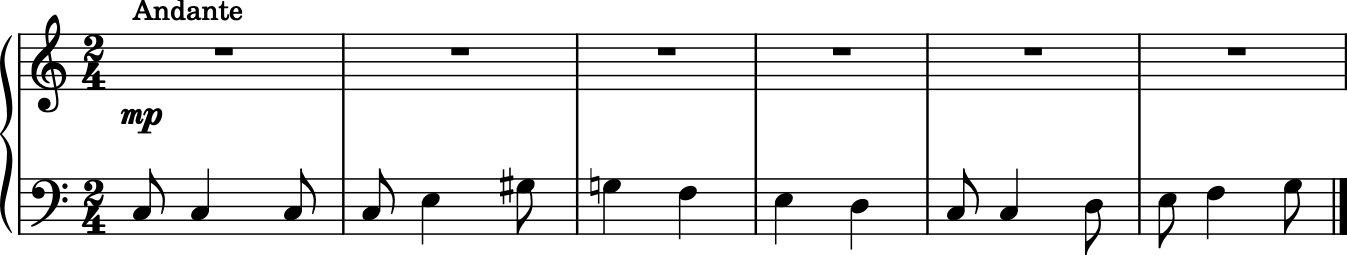

In [5]:
exercise, params = generate_exercise(
    pitch_markov_prob,
    rhythm_dict,
    grade="initial"
)

render_exercise(exercise, params)

Hand pattern: ['R', 'R', 'L', 'L']
(0.5, 0.5, 0.5, 0.5, 0.5, 0.5) 2
(1.0, 1.0, 1.0) 4
(2.0, 1.0) 2
(0.5, 0.5, 0.5, 0.5, 1.0) 168
(0.5, 0.5, 1.0, 1.0) 2
(0.5, 0.5, 2.0) 6
(1.0, 0.5, 0.5, 0.5, 0.5) 7
(1.0, 2.0) 2
(1.0, 1.5, 0.5) 2
(0.5, 0.5, 1.5, 0.5) 2
(1.0, 1.0, 0.5, 0.5) 1
(1.0, 0.5, 0.5, 1.0) 6
(2.0, 0.5, 0.5) 4
(1.5, 0.5, 0.5, 0.5) 4
(0.5, 0.5, 1.0, 0.5, 0.5) 2
(1.5, 0.5, 1.0) 7
(0.5, 1.0, 0.5, 1.0) 1
(0.5, 1.0, 0.5, 0.5, 0.5) 1
(0.5, 2.0, 0.5) 11
(1.0, 0.5, 1.0, 0.5) 4
(0.5, 0.5, 0.5, 1.0, 0.5) 4
(0.5, 1.5, 1.0) 2
(1.0, 0.5, 1.5) 4
(0.5, 1.0, 1.0, 0.5) 1
(0.5, 1.0, 1.5) 1
rhythm_plan: [(0.5, 0.5, 0.5, 0.5, 1.0), (0.5, 0.5, 0.5, 0.5, 1.0), (0.5, 0.5, 1.0, 1.0), (0.5, 0.5, 0.5, 0.5, 1.0)]
generate_exercise: position_notes:[84, 86, 88, 89, 91]
generate_exercise: filtered_notes:[]
generate_exercise: allowed_notes:[]
bar 1, attemt number 0
constrained_transitions: max_interval = 5
constrained_transitions: allowed_notes = {53, 55, 57, 58, 60, 62, 64, 65, 67, 69, 70, 72, 74, 76, 77, 79, 8

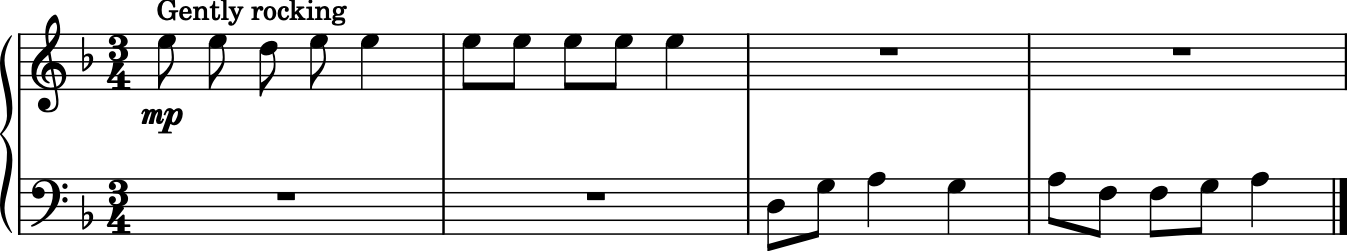

In [7]:
exercise, params = generate_exercise(
    pitch_markov_prob,
    rhythm_dict,
    grade=1 
)

render_exercise(exercise, params)